# Phase 3: Exploratory Data Analysis (EDA)

## Objectives

- Analyze attack distribution
- Visualize class imbalance
- Study feature distributions
- Analyze feature correlations
- Identify outliers
- Generate figures for project report

In [1]:
# ============================================================
# Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_DIR = Path(r"A:\Network-Intrusion-Detection-System")

DATASET_PATH = PROJECT_DIR / "dataset" / "cleaned" / "cleaned_cicids2017.csv"

FIGURE_PATH = PROJECT_DIR / "results" / "figures"

FIGURE_PATH.mkdir(parents=True, exist_ok=True)

In [3]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv(DATASET_PATH)

print(df.shape)

(2522362, 79)


# Attack Distribution

In [5]:
label_counts = df["Label"].value_counts()

print(label_counts)

Label
BENIGN                        2096484
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


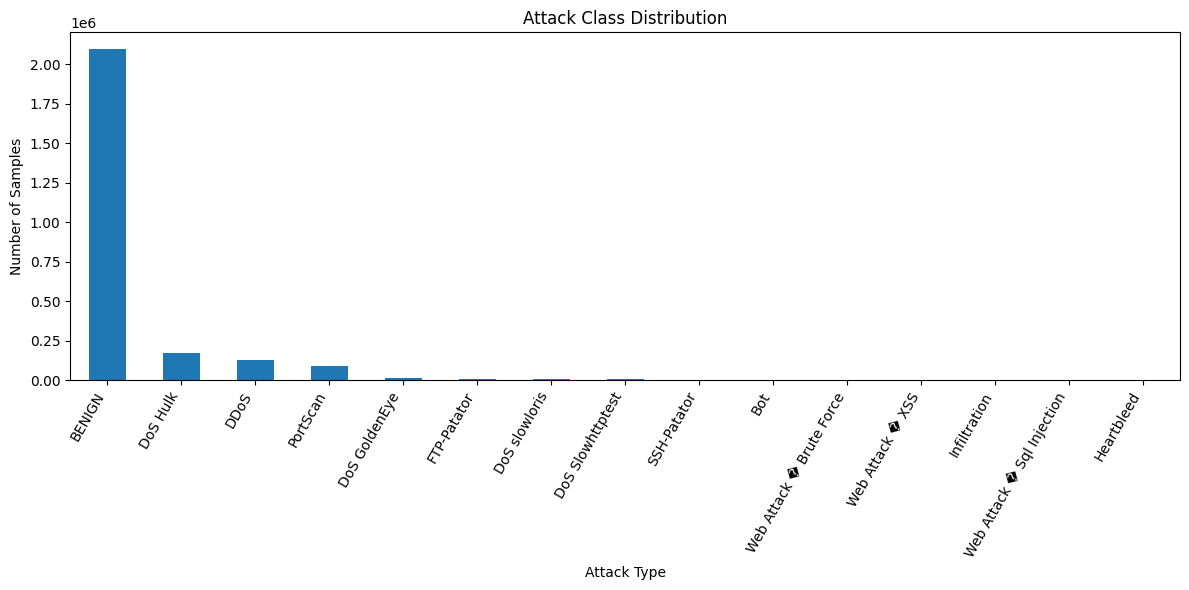

In [8]:
plt.figure(figsize=(12,6))

label_counts.plot(kind="bar")

plt.title("Attack Class Distribution")

plt.xlabel("Attack Type")

plt.ylabel("Number of Samples")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()

plt.savefig(FIGURE_PATH/"attack_distribution_bar.png", dpi=300)

plt.show()

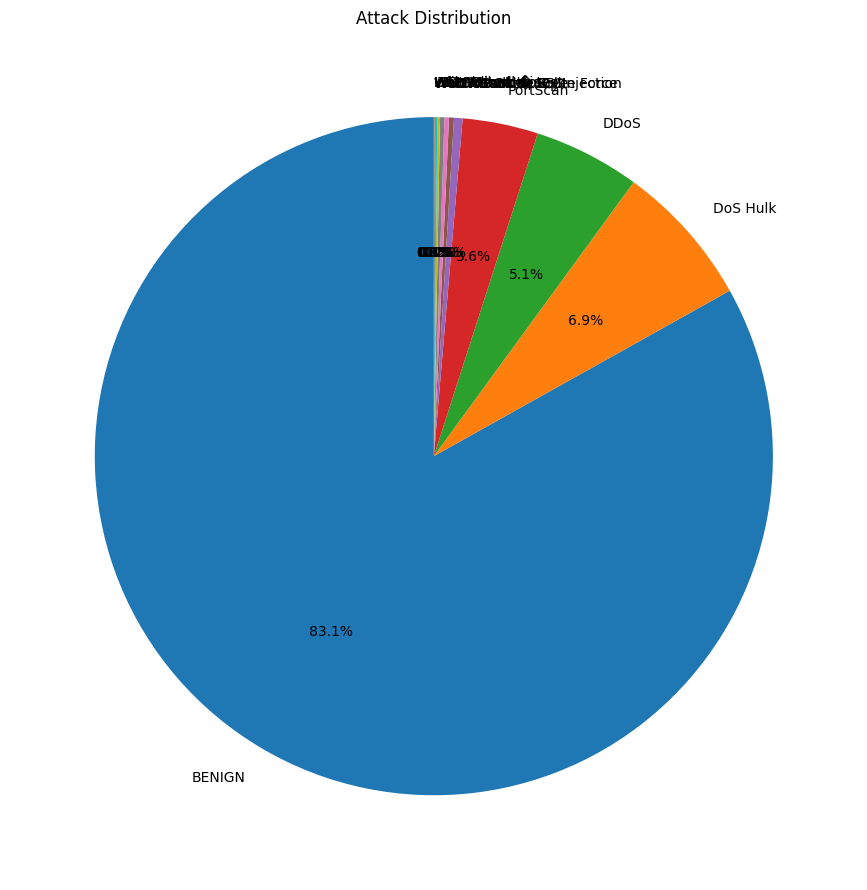

In [7]:
plt.figure(figsize=(9,9))

label_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Attack Distribution")

plt.tight_layout()

plt.savefig(FIGURE_PATH/"attack_distribution_pie.png", dpi=300)

plt.show()

In [9]:
# ============================================================
# Fix Label Encoding
# ============================================================

df["Label"] = (
    df["Label"]
    .str.replace("�", "-", regex=False)
    .str.strip()
)

print(df["Label"].unique())

['BENIGN' 'DDoS' 'PortScan' 'Bot' 'Infiltration'
 'Web Attack - Brute Force' 'Web Attack - XSS'
 'Web Attack - Sql Injection' 'FTP-Patator' 'SSH-Patator' 'DoS slowloris'
 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed']


# Correlation Analysis

In [10]:
# ============================================================
# Correlation Matrix
# ============================================================

numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_df.corr()

print(correlation_matrix.shape)

(78, 78)


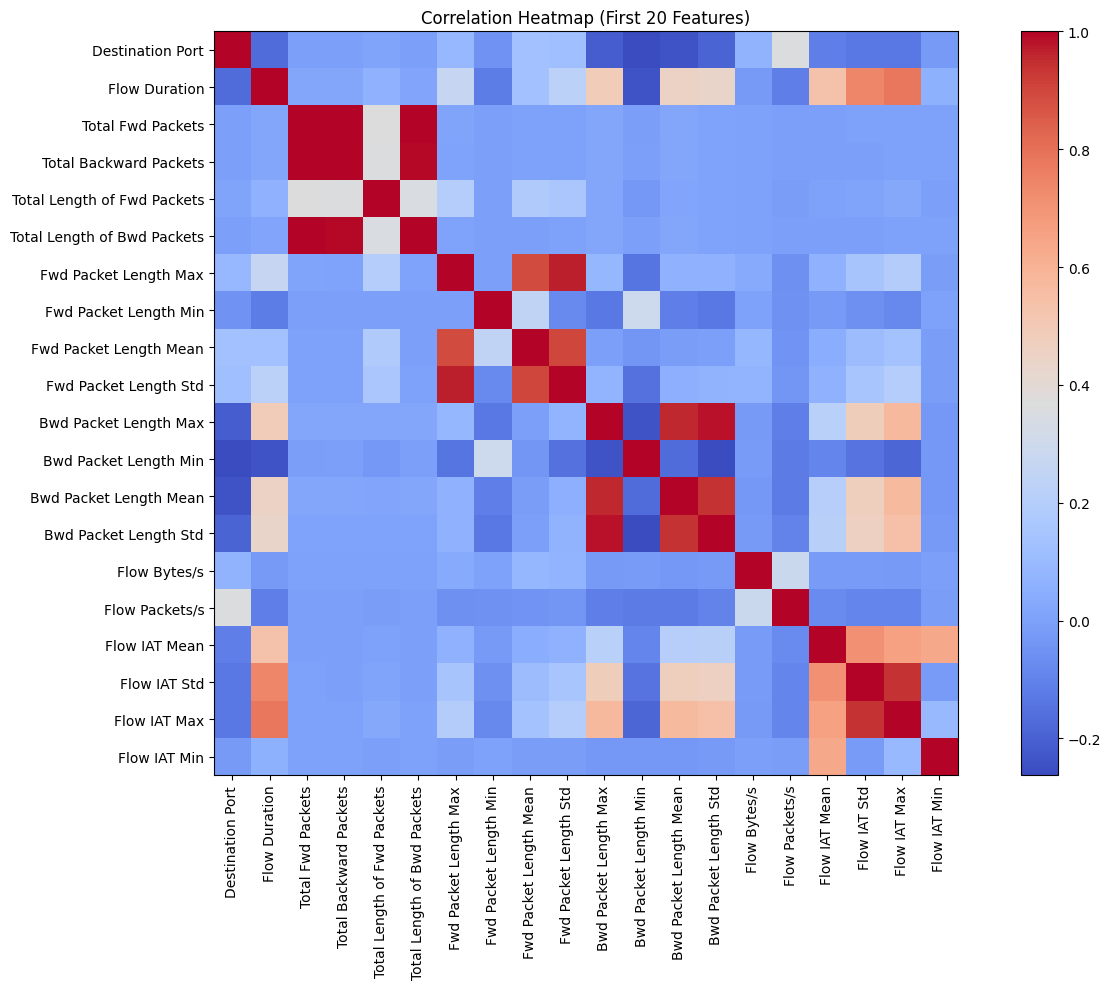

In [11]:
plt.figure(figsize=(14,10))

plt.imshow(
    correlation_matrix.iloc[:20, :20],
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(range(20), correlation_matrix.columns[:20], rotation=90)

plt.yticks(range(20), correlation_matrix.columns[:20])

plt.title("Correlation Heatmap (First 20 Features)")

plt.tight_layout()

plt.savefig(
    FIGURE_PATH / "correlation_heatmap.png",
    dpi=300
)

plt.show()